# Online Retail Sales Analysis

**Dataset:** UCI Online Retail Dataset  
**Tools:** PostgreSQL · Python (pandas, matplotlib)  
**Scope:** Sales trend analysis, RFM customer segmentation, and basic revenue forecasting

---

The dataset contains transactional records from a UK-based online retailer covering roughly one year (2010–2011). Each row represents a product sold in a given invoice, along with customer and country information.

The data was first loaded and cleaned in PostgreSQL, then pulled into Python for analysis and visualization.

## 1. Setup

In [1]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

In [2]:
# PostgreSQL connection
# Replace credentials before running locally
user     = "postgres"
password = quote_plus("Om@135246")
host     = "localhost"
port     = "5432"
database = "retail_db"

engine = create_engine(
    f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}"
)

# Quick check
pd.read_sql("SELECT 1 AS connected", engine)

,connected
0,1


## 2. Data Cleaning (done in SQL)

All cleaning was handled directly in PostgreSQL before pulling data into Python. The steps were:

- **Removed rows with null `CustomerID`** — transactions without a customer ID can't be used for customer-level analysis
- **Removed rows where `Quantity <= 0`** — these represent returns or cancelled orders
- **Fixed the `InvoiceDate` column** — the raw CSV stored dates as text (`MM/DD/YYYY HH:MI`), so a new `TIMESTAMP` column was created using `TO_TIMESTAMP()`, and the old column was dropped
- **Added `TotalPrice`** — calculated as `Quantity × UnitPrice` to get the revenue per line item

The full SQL script is in `Sales_analysis.sql`.

## 3. Pulling Data from PostgreSQL

In [3]:
# Monthly revenue — aggregated at DB level for efficiency
# Note: PostgreSQL returns column aliases in lowercase regardless of how they're written in SQL
monthly = pd.read_sql("""
    SELECT
        DATE_TRUNC('month', invoicedate) AS month,
        SUM(totalprice) AS revenue
    FROM retail_data
    GROUP BY month
    ORDER BY month;
""", engine)

# Rename to title case for cleaner display throughout the notebook
monthly.columns = ['Month', 'Revenue']
monthly['Month'] = pd.to_datetime(monthly['Month'])

monthly.head()

,Month,Revenue
0,2010-12-01,572713.890
1,2011-01-01,569445.040
2,2011-02-01,447137.350
3,2011-03-01,595500.760
4,2011-04-01,469200.361


In [4]:
# Customer-level summary for RFM
customer = pd.read_sql("""
    SELECT
        customerid,
        COUNT(DISTINCT invoiceno) AS frequency,
        SUM(totalprice)           AS monetary,
        MAX(invoicedate)          AS lastpurchase
    FROM retail_data
    GROUP BY customerid;
""", engine)

# Rename to title case
customer.columns = ['CustomerID', 'Frequency', 'Monetary', 'LastPurchase']

customer.head()

,CustomerID,Frequency,Monetary,LastPurchase
0,12346.0,1,77183.60,2011-01-18 10:01:00
1,12347.0,7,4310.00,2011-12-07 15:52:00
2,12348.0,4,1797.24,2011-09-25 13:13:00
3,12349.0,1,1757.55,2011-11-21 09:51:00
4,12350.0,1,334.40,2011-02-02 16:01:00


In [5]:
# Top 10 products by quantity sold
top_products = pd.read_sql("""
    SELECT
        description,
        SUM(quantity) AS totalsold
    FROM retail_data
    GROUP BY description
    ORDER BY totalsold DESC
    LIMIT 10;
""", engine)

top_products.columns = ['Description', 'TotalSold']
top_products

,Description,TotalSold
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,77916
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
3,JUMBO BAG RED RETROSPOT,46181
4,WHITE HANGING HEART T-LIGHT HOLDER,36725
5,ASSORTED COLOUR BIRD ORNAMENT,35362
6,PACK OF 72 RETROSPOT CAKE CASES,33693
7,POPCORN HOLDER,30931
8,RABBIT NIGHT LIGHT,27202
9,MINI PAINT SET VINTAGE,26076


## 4. Sales Trend Analysis

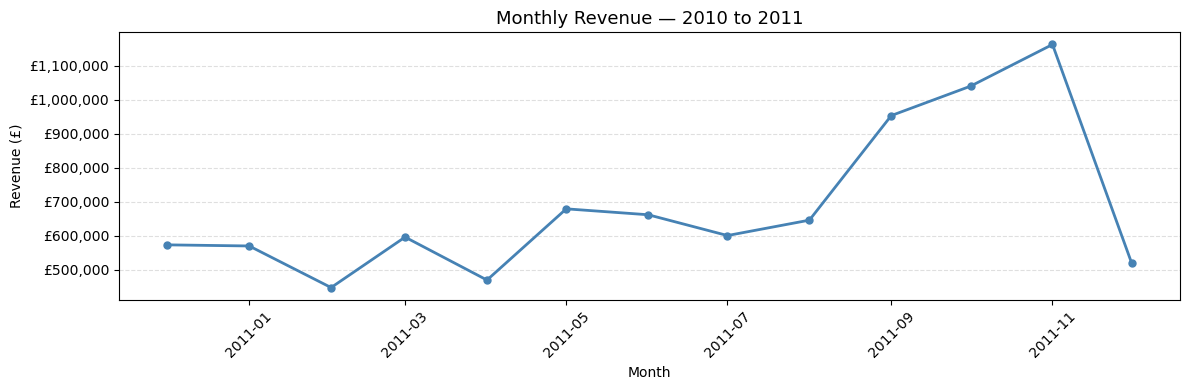

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['Month'], monthly['Revenue'], marker='o', color='steelblue', linewidth=2, markersize=5)
ax.set_title('Monthly Revenue — 2010 to 2011', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

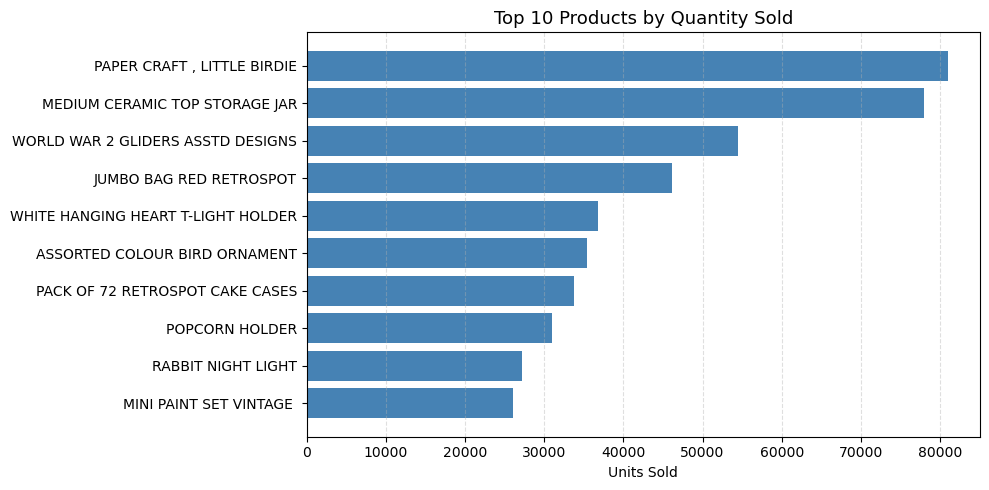

In [7]:
# Top 10 products
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_products['Description'][::-1], top_products['TotalSold'][::-1], color='steelblue')
ax.set_title('Top 10 Products by Quantity Sold', fontsize=13)
ax.set_xlabel('Units Sold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 5. RFM Customer Segmentation

RFM stands for Recency, Frequency, and Monetary — three dimensions that summarize customer purchasing behavior.

- **Recency** — how recently a customer placed an order (fewer days = better)
- **Frequency** — how many times they've ordered
- **Monetary** — how much they've spent in total

Each customer gets a score from 1–4 on each dimension, and the combined score is used to assign them to a segment.

In [8]:
customer['LastPurchase'] = pd.to_datetime(customer['LastPurchase'])

# Snapshot date = one day after the last transaction in the dataset
snapshot_date = customer['LastPurchase'].max() + pd.Timedelta(days=1)
customer['Recency'] = (snapshot_date - customer['LastPurchase']).dt.days

print(f"Reference date used: {snapshot_date.date()}")
customer[['CustomerID', 'Recency', 'Frequency', 'Monetary']].head()

Reference date used: 2011-12-10


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [9]:
# Score each dimension on a 1–4 scale using quartiles
# Recency is reversed — lower days = more recent = higher score
customer['R_score'] = pd.qcut(customer['Recency'],   q=4, labels=[4,3,2,1], duplicates='drop')

f_bins = pd.qcut(customer['Frequency'], q=4, duplicates='drop')
customer['F_score'] = f_bins.cat.codes + 1

m_bins = pd.qcut(customer['Monetary'],  q=4, duplicates='drop')
customer['M_score'] = m_bins.cat.codes + 1

# Combine into a single RFM string, e.g. '432'
customer['RFM_Score'] = (
    customer['R_score'].astype(str) +
    customer['F_score'].astype(str) +
    customer['M_score'].astype(str)
)

customer[['CustomerID', 'R_score', 'F_score', 'M_score', 'RFM_Score']].head()

,CustomerID,R_score,F_score,M_score,RFM_Score
0,12346.0,1,1,4,114
1,12347.0,4,3,4,434
2,12348.0,2,2,4,224
3,12349.0,3,1,4,314
4,12350.0,1,1,2,112


In [10]:
def segment(row):
    if row['F_score'] >= 3 and row['M_score'] >= 3:
        return 'High Value'
    elif row['F_score'] >= 2:
        return 'Loyal'
    else:
        return 'Low Value'

customer['Segment'] = customer.apply(segment, axis=1)
customer['Segment'].value_counts()

Segment
Low Value     2329
Loyal         1146
High Value     864
Name: count, dtype: int64

In [11]:
seg_summary = customer.groupby('Segment').agg(
    Customers  = ('CustomerID', 'count'),
    Revenue    = ('Monetary', 'sum')
).sort_values('Revenue', ascending=False)

seg_summary['Revenue'] = seg_summary['Revenue'].map('£{:,.0f}'.format)
seg_summary

,Customers,Revenue
Segment,,
High Value,864,"£5,902,721"
Loyal,1146,"£1,652,461"
Low Value,2329,"£1,356,225"


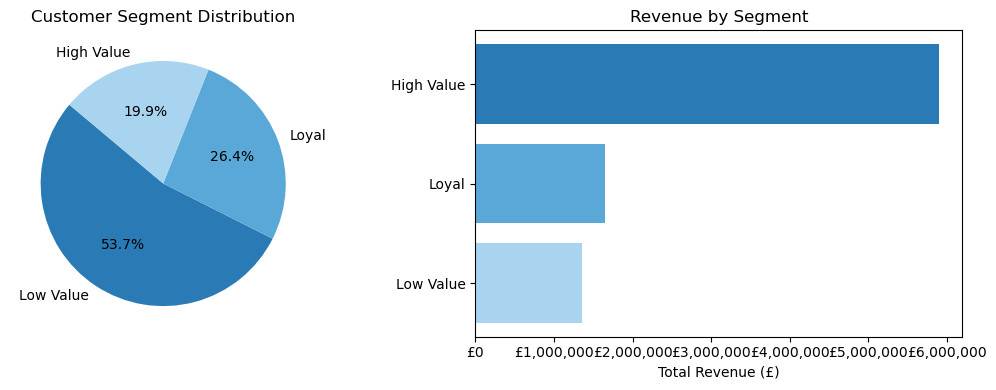

In [12]:
# Segment distribution chart
counts = customer['Segment'].value_counts()
colors = ['#2a7ab5', '#5aa8d8', '#a8d4f0']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=140)
axes[0].set_title('Customer Segment Distribution')

rev_by_seg = customer.groupby('Segment')['Monetary'].sum().sort_values()
axes[1].barh(rev_by_seg.index, rev_by_seg.values, color=colors[::-1])
axes[1].set_title('Revenue by Segment')
axes[1].set_xlabel('Total Revenue (£)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.tight_layout()
plt.show()

## 6. Revenue Forecasting

A 3-month rolling average is used here to smooth the monthly revenue and get a rough sense of the trend direction. It's simple but works well enough for a dataset this size.

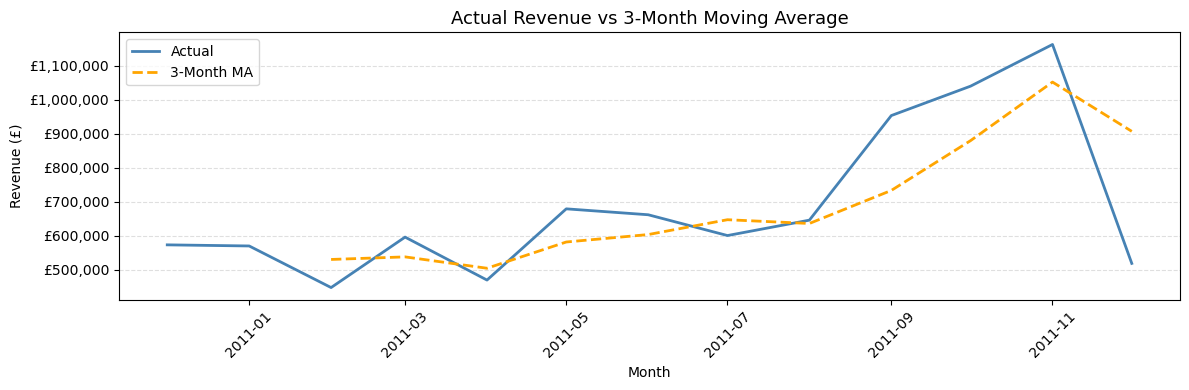

In [13]:
monthly['Forecast'] = monthly['Revenue'].rolling(window=3).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['Month'], monthly['Revenue'],  label='Actual',   color='steelblue', linewidth=2)
ax.plot(monthly['Month'], monthly['Forecast'], label='3-Month MA', color='orange', linewidth=2, linestyle='--')
ax.set_title('Actual Revenue vs 3-Month Moving Average', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Key Findings

**Sales trend**  
Revenue stays relatively flat for most of the year, then climbs sharply between September and November. December shows a dip — likely because the dataset ends mid-month rather than a real drop in sales.

**Top products**  
A small number of products account for a large portion of units sold. Items like "World War 2 Gliders" and "Jumbo Bag" consistently appear in the top 10.

**Customer segments**  
Most customers fall into the Low Value bucket, but High Value customers — though fewer — drive a significantly larger share of revenue. This is a fairly typical pattern in retail data.

**Forecasting**  
The 3-month moving average captures the general trend reasonably well. It lags behind the sharp Q4 spike, which is expected — a moving average doesn't predict sudden jumps, it just smooths what's already happened.

## 8. Export

In [14]:
monthly['Revenue']  = monthly['Revenue'].round(2)
monthly['Forecast'] = monthly['Forecast'].round(2)

monthly.to_csv("monthly_sales.csv", index=False)
customer.to_csv("customer_rfm.csv",  index=False)

print("Saved:")
print(f"  monthly_sales.csv  ({len(monthly)} rows)")
print(f"  customer_rfm.csv   ({len(customer)} rows)")

Saved:
  monthly_sales.csv  (13 rows)
  customer_rfm.csv   (4339 rows)
